In [1]:
import pandas as pd
import numpy as np

# Loading the dataset into a Pandas DataFrame
df = pd.read_csv("Iris.csv")

# Let's check the first 5 rows to ensure the data was loaded successfully
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# 1. Checking for missing values
print("Missing Value Counts:")
print(df.isnull().sum())
print("-" * 30)

# 2. Statistical summary (Describe)
# Even though the 'Id' column is numerical, it doesn't hold statistical meaning.
# Therefore, it is more logical to look at the summary while excluding it.
print("\nStatistical Summary of the Dataset:")
display(df.drop('Id', axis=1).describe())

Missing Value Counts:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
------------------------------

Statistical Summary of the Dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


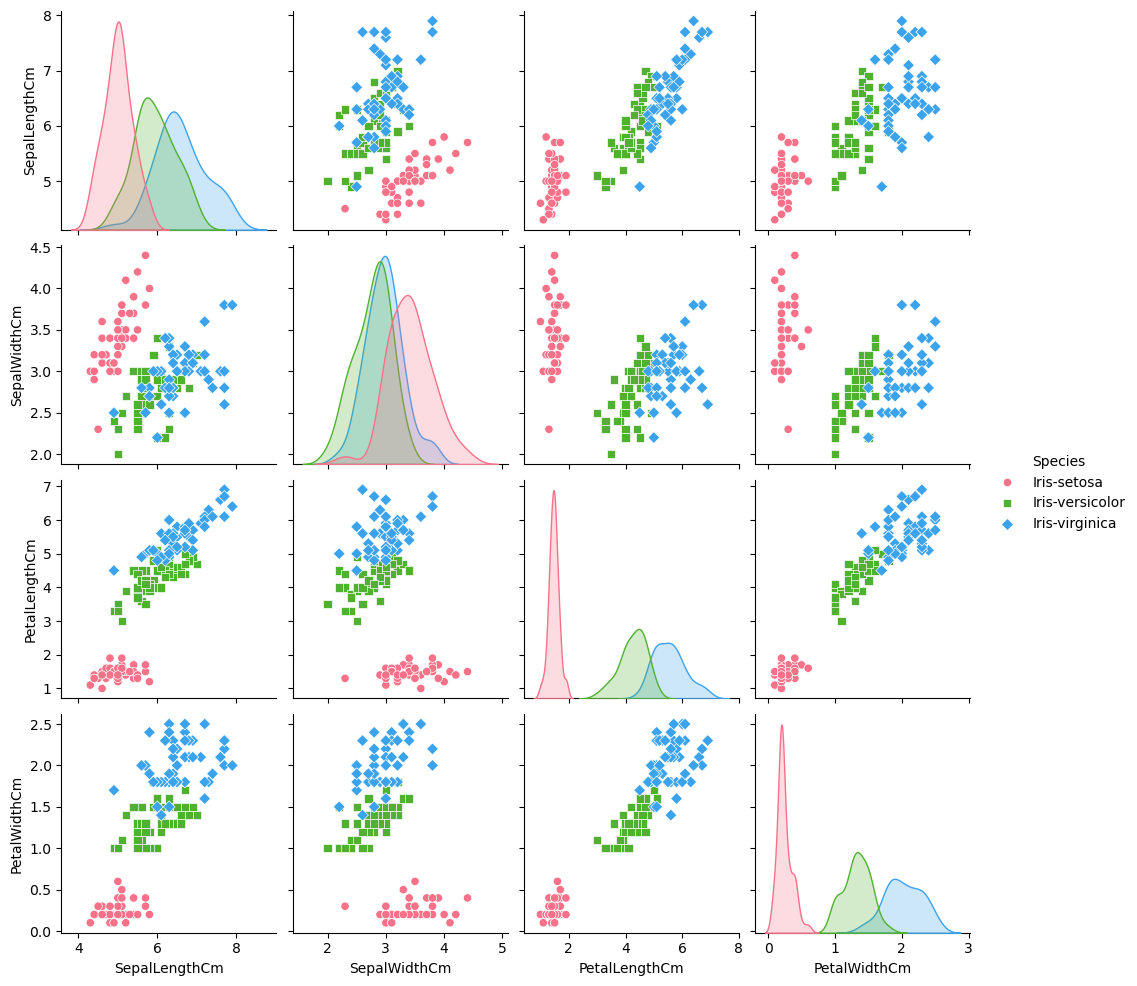

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Since the 'Id' column is just a sequence number, it won't be useful for analysis. 
# We are creating a new variable by dropping it to exclude it from the plots.
df_visual = df.drop('Id', axis=1)

# Plotting the distribution and relationships of all features grouped by species
sns.pairplot(df_visual, hue="Species", palette="husl", markers=["o", "s", "D"])

# Display the plot
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 1. Separating Features (X) and Target Variable (y)
# Features the model will look at (Dropping Id and Species to keep only leaf measurements)
X = df.drop(['Id', 'Species'], axis=1) 

# The target the model will try to predict (Flower species)
y = df['Species'] 

# 2. Splitting the data into 80% Training and 20% Testing
# Using random_state=42 ensures the data is split randomly in the same way every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size (Rows, Columns):", X_train.shape)
print("Test set size (Rows, Columns):", X_test.shape)

Training set size (Rows, Columns): (120, 4)
Test set size (Rows, Columns): (30, 4)


🌟 Best Parameters Found: {'C': 1, 'max_iter': 200, 'solver': 'lbfgs'}

--- Model Performance Metrics ---
Accuracy Score: 1.0000
Log Loss (The lower, the better): 0.1112

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



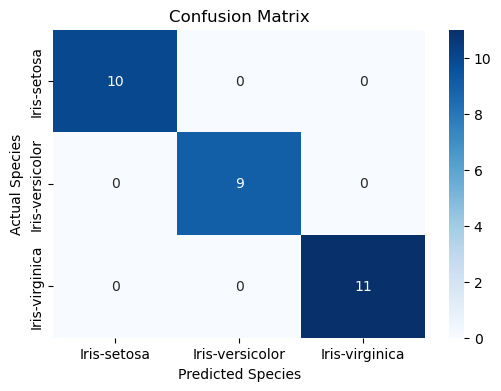

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Defining the Hyperparameter Grid
# C: Regularization coefficient. Prevents the model from overfitting.
# solver: The optimization algorithm running in the background.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'solver': ['lbfgs', 'newton-cg'], 
    'max_iter': [200, 500]
}

# 2. Searching for the Best Model with GridSearchCV
# cv=5 means dividing the data into 5 parts and testing internally to find the most robust model.
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Let's see the best parameters
print(f"🌟 Best Parameters Found: {grid_search.best_params_}")

# 3. Making Predictions with the Best Model
best_log_model = grid_search.best_estimator_
y_pred = best_log_model.predict(X_test)

# To calculate Log Loss, we get the probability values (predict_proba) for the classes
y_pred_proba = best_log_model.predict_proba(X_test) 

# 4. Detailed Error and Performance Metrics
print("\n--- Model Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss (The lower, the better): {log_loss(y_test, y_pred_proba):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_log_model.classes_, 
            yticklabels=best_log_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

🌟 Best Parameters Found for SVC: {'C': 1, 'kernel': 'linear'}

--- SVC Performance Metrics ---
Accuracy Score: 1.0000
Log Loss: 0.0897


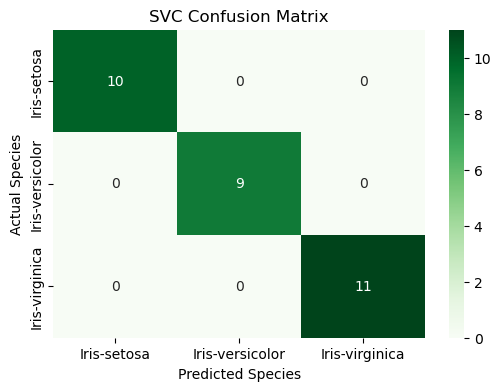

In [6]:
from sklearn.svm import SVC

# 1. Hyperparameter Grid for SVC
# kernel: The type of decision boundary (Should it be linear or curved/rbf?)
# C: How much tolerance we have for margin violations (Low C = Wide margin but more errors, High C = Narrow margin but zero errors)
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Note: SVC does not produce probabilities by default. We set probability=True to calculate Log Loss.
svc_model = SVC(probability=True, random_state=42)

# 2. Searching for the Best SVC with GridSearchCV
grid_search_svc = GridSearchCV(svc_model, param_grid_svc, cv=5, scoring='accuracy')
grid_search_svc.fit(X_train, y_train)

# Let's see the best parameters
print(f"🌟 Best Parameters Found for SVC: {grid_search_svc.best_params_}")

# 3. Prediction and Performance
best_svc = grid_search_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test)
y_pred_proba_svc = best_svc.predict_proba(X_test)

print("\n--- SVC Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_svc):.4f}")

# 4. Confusion Matrix Visualization
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', # Chose green tones for a visual difference
            xticklabels=best_svc.classes_, 
            yticklabels=best_svc.classes_)
plt.title('SVC Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()


--- Naive Bayes Performance Metrics ---
Accuracy Score: 1.0000
Log Loss: 0.0263


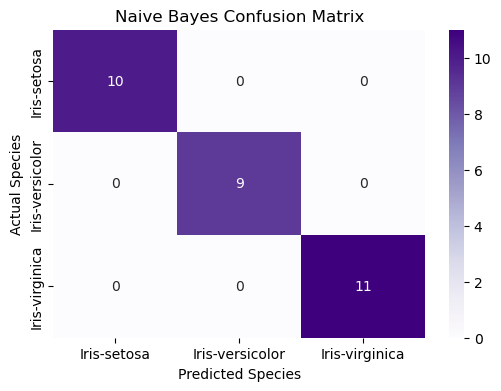

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Defining and Training the Model
# Naive Bayes is very fast and has almost no parameters to tune.
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2. Making Predictions and Getting Probabilities
y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)

# 3. Performance Metrics
print("\n--- Naive Bayes Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_nb):.4f}")

# 4. Confusion Matrix (Let's use Purple tones this time!)
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Naive Bayes Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

🌟 Best Parameters Found for Decision Tree: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}

--- Decision Tree Performance Metrics ---
Accuracy Score: 1.0000
Log Loss: 0.0000


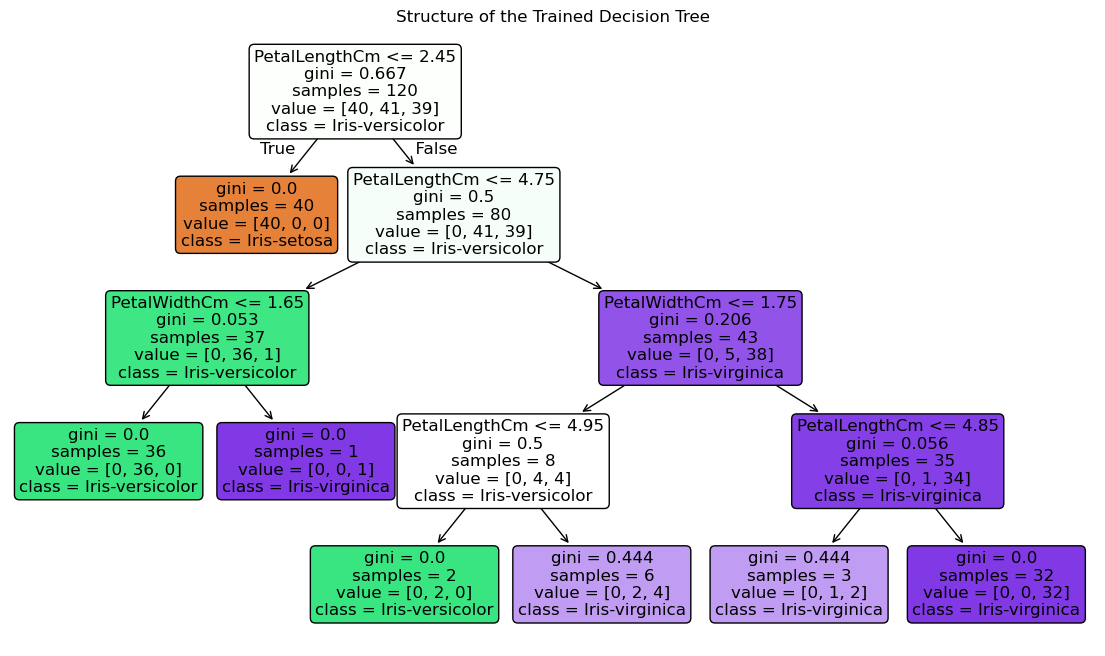

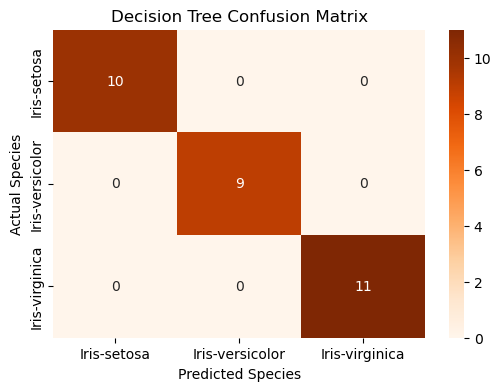

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hyperparameter Grid for Decision Tree
# max_depth: How deep the tree can go in asking questions (Too deep leads to memorizing data - overfitting)
# criterion: The mathematical rule used to choose questions (gini or entropy)
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5]
}

# 2. Defining the Model and Finding the Best Parameters
dt_model = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dt_model, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

print(f"🌟 Best Parameters Found for Decision Tree: {grid_search_dt.best_params_}")

# 3. Prediction and Metrics
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)

print("\n--- Decision Tree Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_dt):.4f}")

# 4. THE BEST PART: VISUALIZING THE TREE!
plt.figure(figsize=(14, 8))
plot_tree(best_dt, 
          feature_names=X.columns, 
          class_names=best_dt.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title('Structure of the Trained Decision Tree')
plt.show()

# 5. Confusion Matrix (Orange tones)
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=best_dt.classes_, 
            yticklabels=best_dt.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

🌟 Best Parameters Found for Random Forest: {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 50}

--- Random Forest Performance Metrics ---
Accuracy Score: 1.0000
Log Loss: 0.0533


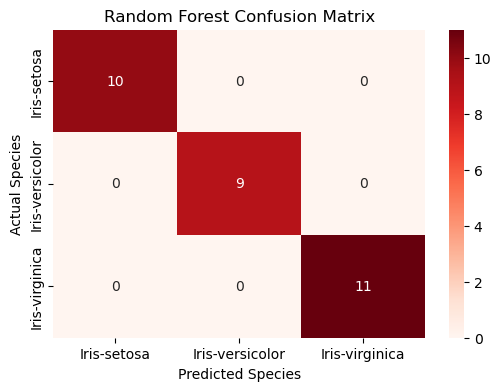

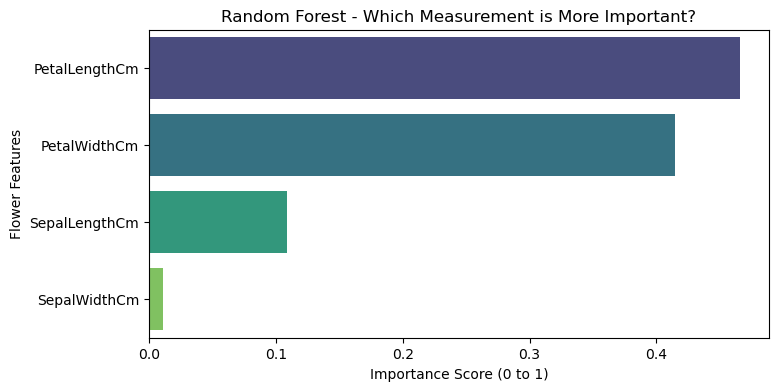

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Hyperparameter Grid
# n_estimators: Number of trees in the forest
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Will try forests with 50, 100, or 200 trees
    'max_depth': [3, 4, 5],
    'criterion': ['gini', 'entropy']
}

# 2. Defining the Model and GridSearch
rf_model = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

print(f"🌟 Best Parameters Found for Random Forest: {grid_search_rf.best_params_}")

# 3. Predictions with the Best Model
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)

# 4. Performance Metrics
print("\n--- Random Forest Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_rf):.4f}")

# 5. Confusion Matrix (Red tones this time!)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', 
            xticklabels=best_rf.classes_, 
            yticklabels=best_rf.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

# 6. DETAILED PART: Feature Importance 
importances = best_rf.feature_importances_
features_df = pd.DataFrame({'Feature': X.columns, 'Importance Score': importances})
features_df = features_df.sort_values(by='Importance Score', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance Score', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest - Which Measurement is More Important?')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Flower Features')
plt.show()

### 📝 Iris Dataset Classification Project: Final Report

**1. Project Objective:**
In this project, machine learning models were developed to predict which of the three different species (*Setosa, Versicolor, Virginica*) an Iris flower belongs to, using petal and sepal measurements from 150 samples.

**2. Model Performance Comparison:**
The results of the five different algorithms trained on the test dataset are as follows:

| Algorithm | Accuracy | Log Loss |
| :--- | :--- | :--- |
| Logistic Regression | 100% | 0.1112 |
| Support Vector Classifier (SVC - Linear) | 100% | 0.0897 |
| Random Forest | 100% | 0.0533 |
| Naive Bayes (Gaussian) | 100% | 0.0263 |
| Decision Tree | 100% | 0.0000 |

*Note: While all models reached a 100% accuracy rate, looking at the **Log Loss** (prediction confidence) metrics shows that Decision Trees and Naive Bayes algorithms experienced the lowest uncertainty while performing classification.*

**3. Key Insights:**
* **Petals are Decisive:** According to the Feature Importance analysis of the Random Forest model, the most critical measurements for determining a flower's species are **Petal Length** and **Petal Width**. Sepal measurements have almost no impact on species differentiation.
* **Flawless Separation of Setosa:** As a result of the Exploratory Data Analysis (EDA) and Decision Tree visualizations, it was observed that *Iris-setosa* is distinctly separated from the other two species. By looking only at the petal length (<= 2.45 cm), one can state with 100% certainty whether a flower is a Setosa or not.

**4. Conclusion:**
The Iris dataset is a clean dataset where classes (especially Setosa) can be separated by very clear boundaries. For this reason, all the basic machine learning models implemented grasped the data perfectly and succeeded in making predictions with zero error.